<a href="https://colab.research.google.com/github/annapo28/MagnitudeInML/blob/CurriculumMagnitude/CurriculumMagnitude.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import json
import os

class MagnitudeRegressionLoss(nn.Module):

    def __init__(self, base_scale=1.0, lambda_reg=0.1, epsilon=1e-6, use_adaptive_t=True):
        super().__init__()
        self.base_scale = base_scale
        self.lambda_reg = lambda_reg
        self.epsilon = epsilon
        self.use_adaptive_t = use_adaptive_t

    def forward(self, y_pred, y_true):
        mse_loss = nn.functional.mse_loss(y_pred, y_true)

        errors = y_true - y_pred
        if self.use_adaptive_t:
            err_std = torch.std(errors) + 1e-8
            t = self.base_scale / err_std
        else:
            t = self.base_scale

        batch_size = errors.shape[0]
        zero_vec = torch.zeros(1, 1, device=errors.device)
        E = torch.cat([errors, zero_vec], dim=0)

        diff = E.unsqueeze(0) - E.unsqueeze(1)
        distances = torch.norm(diff, dim=2, p=2)
        zeta = torch.exp(-t * distances)

        zeta = zeta + self.epsilon * torch.eye(zeta.shape[0], device=zeta.device)

        try:
            ones = torch.ones(zeta.shape[0], 1, device=zeta.device)
            w = torch.linalg.solve(zeta, ones)
            magnitude = torch.sum(w)
            mag_loss = torch.relu(magnitude - 1.0)
        except RuntimeError:
            mag_loss = torch.tensor(0.0, device=y_pred.device)

        return mse_loss + self.lambda_reg * mag_loss

In [ ]:
class CurriculumMagnitudeLoss(nn.Module):
    def __init__(self, t_start=0.1, t_end=10.0, warmup_epochs=20,
                 lambda_reg=0.1, epsilon=1e-6, adaptive_t=True):
        super().__init__()
        self.t_start = t_start
        self.t_end = t_end
        self.warmup_epochs = warmup_epochs
        self.lambda_reg = lambda_reg
        self.epsilon = epsilon
        self.adaptive_t = adaptive_t
        self.current_epoch = 0
        self.current_t = t_start

    def step_epoch(self):
        self.current_epoch += 1
        progress = min(1.0, self.current_epoch / self.warmup_epochs)
        self.current_t = self.t_start + (self.t_end - self.t_start) * (0.5 * (1 - np.cos(np.pi * progress)))
        return self.current_t

    def forward(self, y_pred, y_true):
        mse_loss = nn.functional.mse_loss(y_pred, y_true)

        errors = y_true - y_pred
        if self.adaptive_t:
            err_std = torch.std(errors) + 1e-8
            t = self.current_t / err_std
        else:
            t = self.current_t

        batch_size = errors.shape[0]
        zero_vec = torch.zeros(1, 1, device=errors.device)
        E = torch.cat([errors, zero_vec], dim=0)
        diff = E.unsqueeze(0) - E.unsqueeze(1)
        distances = torch.norm(diff, dim=2, p=2)
        zeta = torch.exp(-t * distances)

        zeta = zeta + self.epsilon * torch.eye(zeta.shape[0], device=zeta.device)

        try:
            ones = torch.ones(zeta.shape[0], 1, device=zeta.device)
            w = torch.linalg.solve(zeta, ones)
            magnitude = torch.sum(w)
            mag_loss = torch.relu(magnitude - 1.0)
        except RuntimeError:
            mag_loss = torch.tensor(0.0, device=y_pred.device)

        return mse_loss + self.lambda_reg * mag_loss

    def get_current_t(self):
        return self.current_t

In [ ]:
class CurriculumCardLoss(nn.Module):
    def __init__(self, num_classes, t_start=0.1, t_end=5.0, warmup_epochs=20,
                 lambda_reg=0.1, epsilon=1e-6, mode='hybrid'):
        super().__init__()
        self.num_classes = num_classes
        self.t_start = t_start
        self.t_end = t_end
        self.warmup_epochs = warmup_epochs
        self.lambda_reg = lambda_reg
        self.epsilon = epsilon
        self.mode = mode
        self.current_epoch = 0
        self.current_t = t_start
        self.cce_loss = nn.CrossEntropyLoss(reduction='none')

    def step_epoch(self):
        self.current_epoch += 1
        progress = min(1.0, self.current_epoch / self.warmup_epochs)
        self.current_t = self.t_start * (self.t_end / self.t_start) ** progress
        return self.current_t

    def forward(self, y_pred_logits, y_true):
        batch_size = y_pred_logits.shape[0]
        device = y_pred_logits.device

        if self.mode == 'hybrid':
            cce_loss = self.cce_loss(y_pred_logits, y_true).mean()
        else:
            cce_loss = torch.tensor(0.0, device=device)

        y_pred_probs = torch.softmax(y_pred_logits, dim=1)
        y_true_onehot = torch.zeros_like(y_pred_probs)
        y_true_onehot.scatter_(1, y_true.unsqueeze(1), 1.0)

        errors = y_true_onehot - y_pred_probs
        zero_vec = torch.zeros(1, self.num_classes, device=device)
        E = torch.cat([errors, zero_vec], dim=0)
        diff = E.unsqueeze(0) - E.unsqueeze(1)
        distances = torch.norm(diff, dim=2, p=2)
        zeta = torch.exp(-self.current_t * distances)
        zeta = zeta + self.epsilon * torch.eye(zeta.shape[0], device=device)

        try:
            ones = torch.ones(zeta.shape[0], 1, device=device)
            w = torch.linalg.solve(zeta, ones)
            magnitude = torch.sum(w)
            mag_loss = torch.relu(magnitude - 1.0)
        except RuntimeError:
            mag_loss = torch.tensor(0.0, device=device)

        return cce_loss + self.lambda_reg * mag_loss

    def get_current_t(self):
        return self.current_t

In [ ]:
class RegressionNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

def create_outlier_dataset(n_samples=1000, n_features=20, outlier_frac=0.1):
    X, y = make_regression(n_samples=n_samples, n_features=n_features,
                           noise=10, random_state=42)
    y = y.reshape(-1, 1)

    n_outliers = int(n_samples * outlier_frac)
    outlier_idx = np.random.choice(n_samples, n_outliers, replace=False)
    y[outlier_idx] += np.random.uniform(50, 100, size=n_outliers).reshape(-1, 1)

    return X, y

def train_model_curriculum(model, loader, loss_fn, optimizer, epochs=50, is_curriculum=False):
    model.train()
    history = {'loss': [], 't_values': []}

    for epoch in range(epochs):
        epoch_loss = 0.0
        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        history['loss'].append(epoch_loss / len(loader))

        if is_curriculum and hasattr(loss_fn, 'step_epoch'):
            current_t = loss_fn.step_epoch()
            history['t_values'].append(current_t)
        else:
            history['t_values'].append(getattr(loss_fn, 'current_t', 1.0))

    return history

if __name__ == "__main__":
    X, y = create_outlier_dataset(n_samples=2000, outlier_frac=0.15)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    to_tensor = lambda x: torch.FloatTensor(x)
    train_loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(to_tensor(X_train), to_tensor(y_train)),
        batch_size=64, shuffle=True
    )

    results = {}
    histories = {}

    print("Обучение с MSE")
    model_mse = RegressionNet(X_train.shape[1])
    opt_mse = optim.Adam(model_mse.parameters(), lr=0.01)
    loss_mse = nn.MSELoss()
    histories['mse'] = train_model_curriculum(model_mse, train_loader, loss_mse, opt_mse, epochs=50)
    results['mse'] = {'model': model_mse, 'loss': 'MSE'}

    print("Обучение с MAE")
    model_mae = RegressionNet(X_train.shape[1])
    opt_mae = optim.Adam(model_mae.parameters(), lr=0.01)
    loss_mae = nn.L1Loss()
    histories['mae'] = train_model_curriculum(model_mae, train_loader, loss_mae, opt_mae, epochs=50)
    results['mae'] = {'model': model_mae, 'loss': 'MAE'}

    print("Обучение с Static Magnitude Loss (t=1.0)")
    model_static = RegressionNet(X_train.shape[1])
    opt_static = optim.Adam(model_static.parameters(), lr=0.01)
    loss_static = CurriculumMagnitudeLoss(t_start=1.0, t_end=1.0, warmup_epochs=50, lambda_reg=0.1)
    histories['static_mag'] = train_model_curriculum(model_static, train_loader, loss_static, opt_static, epochs=50)
    results['static_mag'] = {'model': model_static, 'loss': 'Static Magnitude'}

    print("Обучение с Curriculum Magnitude Loss (t: 0.1 -> 10.0)")
    model_curr = RegressionNet(X_train.shape[1])
    opt_curr = optim.Adam(model_curr.parameters(), lr=0.01)
    loss_curr = CurriculumMagnitudeLoss(t_start=0.1, t_end=10.0, warmup_epochs=20, lambda_reg=0.1)
    histories['curriculum'] = train_model_curriculum(model_curr, train_loader, loss_curr, opt_curr, epochs=50, is_curriculum=True)
    results['curriculum'] = {'model': model_curr, 'loss': 'Curriculum Magnitude'}

    def evaluate(model, X, y):
        model.eval()
        with torch.no_grad():
            pred = model(to_tensor(X))
            mae = torch.mean(torch.abs(pred - to_tensor(y))).item()
            mse = torch.mean((pred - to_tensor(y))**2).item()
        return mae, mse

    print(f"{'Метод':<25} | {'Test MAE':<12} | {'Test MSE':<12}")
    print("-" * 55)

    table_data = []
    for name, data in results.items():
        mae, mse = evaluate(data['model'], X_test, y_test)
        print(f"{data['loss']:<25} | {mae:<12.4f} | {mse:<12.4f}")
        table_data.append({'method': data['loss'], 'mae': mae, 'mse': mse})

    os.makedirs('results', exist_ok=True)

    with open('results/test_metrics.json', 'w') as f:
        json.dump(table_data, f, indent=2)

    with open('results/training_history.json', 'w') as f:
        serializable_history = {}
        for key, hist in histories.items():
            serializable_history[key] = {
                'loss': [float(x) for x in hist['loss']],
                't_values': [float(x) for x in hist['t_values']]
            }
        json.dump(serializable_history, f, indent=2)

    print("\nРезультаты сохранены в папку results/")

Обучение с MSE
Обучение с MAE
Обучение с Static Magnitude Loss (t=1.0)
Обучение с Curriculum Magnitude Loss (t: 0.1 -> 10.0)
Метод                     | Test MAE     | Test MSE    
-------------------------------------------------------
MSE                       | 22.6924      | 1060.0769   
MAE                       | 21.4580      | 1039.5330   
Static Magnitude          | 24.8836      | 1174.7329   
Curriculum Magnitude      | 24.8074      | 1131.5708   

Результаты сохранены в папку results/


График сохранён: results/curriculum_comparison.png


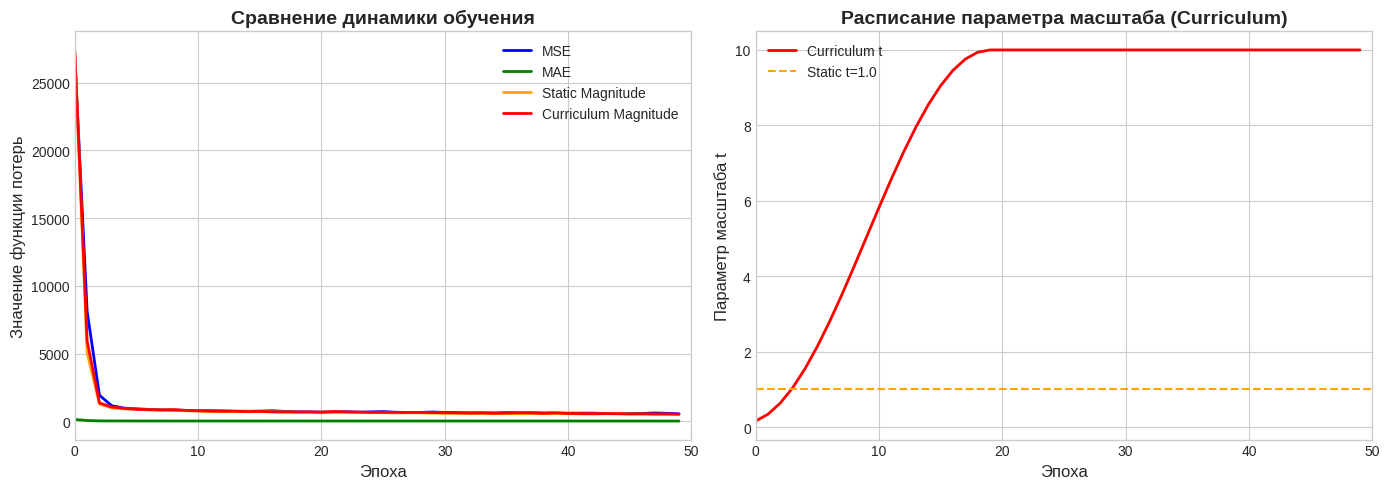

\begin{table}[h]
\centering
\caption{Сравнение методов на тестовой выборке с выбросами}
\begin{tabular}{lcc}
\toprule
Метод & Test MAE $\downarrow$ & Test MSE $\downarrow$ \\
\midrule
MSE & 22.6924 & 1060.0769 \\
MAE & 21.4580 & 1039.5330 \\
Static Magnitude & 24.8836 & 1174.7329 \\
Curriculum Magnitude & 24.8074 & 1131.5708 \\
\bottomrule
\end{tabular}
\end{table}


In [ ]:
with open('results/training_history.json', 'r') as f:
    history = json.load(f)

with open('results/test_metrics.json', 'r') as f:
    metrics = json.load(f)

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
colors = {'mse': 'blue', 'mae': 'green', 'static_mag': 'orange', 'curriculum': 'red'}
labels = {'mse': 'MSE', 'mae': 'MAE', 'static_mag': 'Static Magnitude', 'curriculum': 'Curriculum Magnitude'}

for method, hist in history.items():
    ax1.plot(hist['loss'], label=labels[method], color=colors[method], linewidth=2)

ax1.set_xlabel('Эпоха', fontsize=12)
ax1.set_ylabel('Значение функции потерь', fontsize=12)
ax1.set_title('Сравнение динамики обучения', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right')
ax1.set_xlim(0, 50)

ax2 = axes[1]
ax2.plot(history['curriculum']['t_values'], label='Curriculum t', color='red', linewidth=2)
ax2.axhline(y=history['static_mag']['t_values'][0], color='orange', linestyle='--', label='Static t=1.0')
ax2.set_xlabel('Эпоха', fontsize=12)
ax2.set_ylabel('Параметр масштаба t', fontsize=12)
ax2.set_title('Расписание параметра масштаба (Curriculum)', fontsize=14, fontweight='bold')
ax2.legend(loc='upper left')
ax2.set_xlim(0, 50)

plt.tight_layout()
plt.savefig('results/curriculum_comparison.png', dpi=300, bbox_inches='tight')
print("График сохранён: results/curriculum_comparison.png")
plt.show()

print("\\begin{table}[h]")
print("\\centering")
print("\\caption{Сравнение методов на тестовой выборке с выбросами}")
print("\\begin{tabular}{lcc}")
print("\\toprule")
print("Метод & Test MAE $\\downarrow$ & Test MSE $\\downarrow$ \\\\")
print("\\midrule")
for row in metrics:
    print(f"{row['method']} & {row['mae']:.4f} & {row['mse']:.4f} \\\\")
print("\\bottomrule")
print("\\end{tabular}")
print("\\end{table}")

In [ ]:
class CurriculumMagnitudeLossV2(nn.Module):
    def __init__(self, t_start=0.01, t_end=2.0, warmup_epochs=30,
                 lambda_start=0.01, lambda_end=0.1, epsilon=1e-6,
                 adaptive_t=False, geometric_schedule=True):
        super().__init__()
        self.t_start = t_start
        self.t_end = t_end
        self.warmup_epochs = warmup_epochs
        self.lambda_start = lambda_start
        self.lambda_end = lambda_end
        self.epsilon = epsilon
        self.adaptive_t = adaptive_t
        self.geometric_schedule = geometric_schedule
        self.current_epoch = 0
        self.current_t = t_start
        self.current_lambda = lambda_start

    def step_epoch(self):
        self.current_epoch += 1
        progress = min(1.0, self.current_epoch / self.warmup_epochs)

        if self.geometric_schedule:
            self.current_t = self.t_start * (self.t_end / self.t_start) ** progress
        else:
            self.current_t = self.t_start + (self.t_end - self.t_start) * (0.5 * (1 - np.cos(np.pi * progress)))

        self.current_lambda = self.lambda_start + (self.lambda_end - self.lambda_start) * progress

        return self.current_t, self.current_lambda

    def forward(self, y_pred, y_true):
        mse_loss = nn.functional.mse_loss(y_pred, y_true)

        errors = y_true - y_pred

        if self.adaptive_t:
            err_std = torch.std(errors) + 1e-8
            t = self.current_t / err_std
        else:
            t = self.current_t

        batch_size = errors.shape[0]
        zero_vec = torch.zeros(1, 1, device=errors.device)
        E = torch.cat([errors, zero_vec], dim=0)

        diff = E.unsqueeze(0) - E.unsqueeze(1)
        distances = torch.norm(diff, dim=2, p=2)
        zeta = torch.exp(-t * distances)

        zeta = zeta + self.epsilon * torch.eye(zeta.shape[0], device=zeta.device)

        try:
            ones = torch.ones(zeta.shape[0], 1, device=zeta.device)
            w = torch.linalg.solve(zeta, ones)
            magnitude = torch.sum(w)
            mag_loss = torch.relu(magnitude - 1.0)
        except RuntimeError:
            mag_loss = torch.tensor(0.0, device=y_pred.device)

        return mse_loss + self.current_lambda * mag_loss

    def get_current_params(self):
        return self.current_t, self.current_lambda

In [ ]:
if __name__ == "__main__":
    X, y = create_outlier_dataset(n_samples=2000, outlier_frac=0.15)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    to_tensor = lambda x: torch.FloatTensor(x)
    train_loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(to_tensor(X_train), to_tensor(y_train)),
        batch_size=64, shuffle=True
    )

    results = {}
    histories = {}

    print("Обучение с MSE")
    model_mse = RegressionNet(X_train.shape[1])
    opt_mse = optim.Adam(model_mse.parameters(), lr=0.01)
    loss_mse = nn.MSELoss()
    histories['mse'] = train_model_curriculum(model_mse, train_loader, loss_mse, opt_mse, epochs=50)
    results['mse'] = {'model': model_mse, 'loss': 'MSE'}

    print("Обучение с MAE")
    model_mae = RegressionNet(X_train.shape[1])
    opt_mae = optim.Adam(model_mae.parameters(), lr=0.01)
    loss_mae = nn.L1Loss()
    histories['mae'] = train_model_curriculum(model_mae, train_loader, loss_mae, opt_mae, epochs=50)
    results['mae'] = {'model': model_mae, 'loss': 'MAE'}

    print("Обучение с Static Magnitude Loss (t=1.0)")
    model_static = RegressionNet(X_train.shape[1])
    opt_static = optim.Adam(model_static.parameters(), lr=0.01)
    loss_static = CurriculumMagnitudeLoss(t_start=1.0, t_end=1.0, warmup_epochs=50, lambda_reg=0.1)
    histories['static_mag'] = train_model_curriculum(model_static, train_loader, loss_static, opt_static, epochs=50)
    results['static_mag'] = {'model': model_static, 'loss': 'Static Magnitude'}

    print("Обучение с Curriculum Magnitude Loss (t: 0.1 -> 10.0)")
    model_curr = RegressionNet(X_train.shape[1])
    opt_curr = optim.Adam(model_curr.parameters(), lr=0.01)
    loss_curr = CurriculumMagnitudeLoss(t_start=0.1, t_end=10.0, warmup_epochs=20, lambda_reg=0.1)
    histories['curriculum'] = train_model_curriculum(model_curr, train_loader, loss_curr, opt_curr, epochs=50, is_curriculum=True)
    results['curriculum'] = {'model': model_curr, 'loss': 'Curriculum Magnitude'}

    print("Обучение с Curriculum Magnitude Loss V2")
    model_curr_v2 = RegressionNet(X_train.shape[1])
    opt_curr_v2 = optim.Adam(model_curr_v2.parameters(), lr=0.01)
    loss_curr_v2 = CurriculumMagnitudeLossV2(
        t_start=0.01,
        t_end=2.0,
        warmup_epochs=30,
        lambda_start=0.01,
        lambda_end=0.1,
        adaptive_t=False,
        geometric_schedule=True
    )
    histories['curriculum_v2'] = train_model_curriculum(
        model_curr_v2, train_loader, loss_curr_v2, opt_curr_v2,
        epochs=50, is_curriculum=True
    )
    results['curriculum_v2'] = {'model': model_curr_v2, 'loss': 'Curriculum Magnitude V2'}

    def evaluate(model, X, y):
        model.eval()
        with torch.no_grad():
            pred = model(to_tensor(X))
            mae = torch.mean(torch.abs(pred - to_tensor(y))).item()
            mse = torch.mean((pred - to_tensor(y))**2).item()
        return mae, mse

    print("Результаты на тесте (с выбросами)")
    print(f"{'Метод':<25} | {'Test MAE':<12} | {'Test MSE':<12}")
    print("-" * 55)

    table_data = []
    for name, data in results.items():
        mae, mse = evaluate(data['model'], X_test, y_test)
        print(f"{data['loss']:<25} | {mae:<12.4f} | {mse:<12.4f}")
        table_data.append({'method': data['loss'], 'mae': mae, 'mse': mse})

    os.makedirs('results', exist_ok=True)

    with open('results/test_metrics.json', 'w') as f:
        json.dump(table_data, f, indent=2)

    with open('results/training_history.json', 'w') as f:
        serializable_history = {}
        for key, hist in histories.items():
            loss_values = [float(x) for x in hist['loss']]

            t_values_raw = hist['t_values']
            t_values = []
            for x in t_values_raw:
                if isinstance(x, tuple):
                    t_values.append(float(x[0]))
                else:
                    t_values.append(float(x))

            serializable_history[key] = {
                'loss': loss_values,
                't_values': t_values
            }
        json.dump(serializable_history, f, indent=2)

    print("Результаты сохранены в папку results/")

Обучение с MSE
Обучение с MAE
Обучение с Static Magnitude Loss (t=1.0)
Обучение с Curriculum Magnitude Loss (t: 0.1 -> 10.0)
Обучение с Curriculum Magnitude Loss V2
Результаты на тесте (с выбросами)
Метод                     | Test MAE     | Test MSE    
-------------------------------------------------------
MSE                       | 26.4460      | 1124.1555   
MAE                       | 20.6618      | 1046.3413   
Static Magnitude          | 25.3541      | 1155.4404   
Curriculum Magnitude      | 24.1176      | 1104.0288   
Curriculum Magnitude V2   | 26.6059      | 1141.3855   
Результаты сохранены в папку results/


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
import scipy.stats as stats


def create_imbalanced_dataset(n_samples=5000, n_classes=10, n_features=20,
                              majority_frac=0.9, random_state=42):
    weights = [majority_frac] + [(1 - majority_frac) / (n_classes - 1)] * (n_classes - 1)
    return make_classification(
        n_samples=n_samples, n_features=n_features, n_informative=15,
        n_redundant=5, n_classes=n_classes, n_clusters_per_class=1,
        weights=weights, random_state=random_state
    )


class ClassifierNet(nn.Module):
    def __init__(self, input_dim, n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        return self.net(x)


def compute_magnitude_loss(logits, y_true, t, num_classes, epsilon, device):
    probs = torch.softmax(logits, dim=1)
    onehot = torch.zeros_like(probs).scatter_(1, y_true.unsqueeze(1), 1.0)
    errors = onehot - probs

    zero_vec = torch.zeros(1, num_classes, device=device)
    E = torch.cat([errors, zero_vec], dim=0)

    diff = E.unsqueeze(0) - E.unsqueeze(1)
    distances = torch.norm(diff, dim=2, p=2)

    zeta = torch.exp(-t * distances) + epsilon * torch.eye(E.shape[0], device=device)

    try:
        w = torch.linalg.solve(zeta, torch.ones(E.shape[0], 1, device=device))
        return torch.relu(torch.sum(w) - 1.0)
    except RuntimeError:
        return torch.tensor(0.0, device=device)


class StaticCardLoss(nn.Module):
    def __init__(self, num_classes, t=1.0, lambda_reg=0.1, epsilon=1e-6):
        super().__init__()
        self.num_classes = num_classes
        self.t = t
        self.lambda_reg = lambda_reg
        self.epsilon = epsilon
        self.cce = nn.CrossEntropyLoss()

    def forward(self, logits, y_true):
        mag_loss = compute_magnitude_loss(
            logits, y_true, self.t, self.num_classes, self.epsilon, logits.device
        )
        return self.cce(logits, y_true) + self.lambda_reg * mag_loss


class CurriculumCardLossV1(nn.Module):
    def __init__(self, num_classes, t_start=0.1, t_end=10.0, warmup_epochs=20,
                 lambda_reg=0.1, epsilon=1e-6):
        super().__init__()
        self.num_classes = num_classes
        self.t_start = t_start
        self.t_end = t_end
        self.warmup_epochs = warmup_epochs
        self.lambda_reg = lambda_reg
        self.epsilon = epsilon
        self.current_epoch = 0
        self.current_t = t_start
        self.cce = nn.CrossEntropyLoss()

    def step_epoch(self):
        self.current_epoch += 1
        progress = min(1.0, self.current_epoch / self.warmup_epochs)
        self.current_t = self.t_start + (self.t_end - self.t_start) * \
                         0.5 * (1 - np.cos(np.pi * progress))

    def forward(self, logits, y_true):
        mag_loss = compute_magnitude_loss(
            logits, y_true, self.current_t, self.num_classes, self.epsilon, logits.device
        )
        return self.cce(logits, y_true) + self.lambda_reg * mag_loss


class CurriculumCardLossV2(nn.Module):
    def __init__(self, num_classes, t_start=0.01, t_end=2.0, warmup_epochs=30,
                 lambda_start=0.01, lambda_end=0.1, epsilon=1e-6):
        super().__init__()
        self.num_classes = num_classes
        self.t_start = t_start
        self.t_end = t_end
        self.warmup_epochs = warmup_epochs
        self.lambda_start = lambda_start
        self.lambda_end = lambda_end
        self.epsilon = epsilon
        self.current_epoch = 0
        self.current_t = t_start
        self.current_lambda = lambda_start
        self.cce = nn.CrossEntropyLoss()

    def step_epoch(self):
        self.current_epoch += 1
        progress = min(1.0, self.current_epoch / self.warmup_epochs)
        self.current_t = self.t_start * (self.t_end / self.t_start) ** progress
        self.current_lambda = self.lambda_start + \
                              (self.lambda_end - self.lambda_start) * progress

    def forward(self, logits, y_true):
        mag_loss = compute_magnitude_loss(
            logits, y_true, self.current_t, self.num_classes, self.epsilon, logits.device
        )
        return self.cce(logits, y_true) + self.current_lambda * mag_loss


def train_and_evaluate(loss_fn, X_train, y_train, X_test, y_test,
                       n_seeds=30, epochs=50, is_curriculum=False):
    f1_scores = []
    X_train_t = torch.FloatTensor(X_train)
    y_train_t = torch.LongTensor(y_train)
    X_test_t = torch.FloatTensor(X_test)

    for seed in range(n_seeds):
        torch.manual_seed(seed)
        np.random.seed(seed)

        model = ClassifierNet(X_train.shape[1], n_classes=10)
        optimizer = optim.Adam(model.parameters(), lr=1e-3)

        g = torch.Generator().manual_seed(seed)
        loader = torch.utils.data.DataLoader(
            torch.utils.data.TensorDataset(X_train_t, y_train_t),
            batch_size=64, shuffle=True, generator=g
        )

        model.train()
        for epoch in range(epochs):
            for X_batch, y_batch in loader:
                optimizer.zero_grad()
                loss = loss_fn(model(X_batch), y_batch)
                loss.backward()
                optimizer.step()
            if is_curriculum and hasattr(loss_fn, 'step_epoch'):
                loss_fn.step_epoch()

        model.eval()
        with torch.no_grad():
            preds = torch.argmax(model(X_test_t), dim=1).numpy()
        f1_scores.append(f1_score(y_test, preds, average='macro'))

    return np.array(f1_scores)


if __name__ == "__main__":
    N_CLASSES = 10
    N_SEEDS = 30

    X, y = create_imbalanced_dataset(random_state=42)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    experiments = {
        'CrossEntropy': (nn.CrossEntropyLoss(), False),
        'StaticCardLoss': (StaticCardLoss(N_CLASSES, t=1.0), False),
        'CurrV1': (CurriculumCardLossV1(N_CLASSES), True),
        'CurrV2': (CurriculumCardLossV2(N_CLASSES), True),
    }

    results = {}
    for name, (loss_fn, is_curr) in experiments.items():
        print(f"{name}...")
        results[name] = train_and_evaluate(
            loss_fn, X_train, y_train, X_test, y_test,
            n_seeds=N_SEEDS, is_curriculum=is_curr
        )

    baseline = results['CrossEntropy']
    print(f"\n{'Method':<20} | {'F1-Macro mean±std':^22} | {'p vs CE':^18}")
    print("-" * 65)

    for name, scores in results.items():
        if name == 'CrossEntropy':
            p_str = "—"
        else:
            _, p_val = stats.ttest_rel(baseline, scores)
            p_str = f"{p_val:.4f}"

        mean_f1 = np.mean(scores)
        std_f1 = np.std(scores)
        print(f"{name:<20} | {mean_f1:>8.4f} ± {std_f1:<8.4f} | {p_str:^18}")

    _, p_v1_v2 = stats.ttest_rel(results['CurrV1'], results['CurrV2'])
    print(f"\nCurrV1 vs CurrV2: p={p_v1_v2:.4f}")

CrossEntropy...
StaticCardLoss...
CurrV1...
CurrV2...

Метод                |   F1-Macro mean±std    | p vs CrossEntropy 
--------------------------------------------------------------------
CrossEntropy         |   0.6110 ± 0.0277   |         —         
StaticCardLoss       |   0.6255 ± 0.0266   |       0.0008      
CurrV1               |   0.6318 ± 0.0223   |       0.0006      
CurrV2               |   0.6351 ± 0.0283   |       0.0000      

CurrV1 vs CurrV2: p=0.5528
